# Makemore Multi Layer Percepton name Generator
I'll try this with the dataset already shipped on github and then I'll create my own.

In [13]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

NOTE:
*Some part of code uses cuda acceleration it will work for you both ways because I added check if you have cuda or not but it might run little slower I thought it might be nice thing to say so that anyone reading this gets warned beforehand :P. Below you can check if you will use cuda acceleration or not.*

In [14]:
if torch.cuda.is_available():
    n = torch.cuda.device_count()
    print(f'Found {n} {"GPUs" if n > 1 else "GPU"}:')
    for i in range(n):
        prop = torch.cuda.get_device_properties(i)
        print(f'GPU({i}): VRAM {prop.total_memory / (1024 ** 3):.2f}GB - {prop.name} is available.')
else:
    print("No GPU available. Training will run on CPU.")

Found 1 GPU:
GPU(0): VRAM 6.00GB - NVIDIA GeForce GTX 1660 SUPER is available.


## Dataset from github

In [15]:
general_names = open('data/text/general-names.txt', 'r').read().splitlines()

In [16]:
chars = sorted(list(set(''.join(general_names))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [17]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in general_names:

  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X, device=torch.device('cuda') if torch.cuda.is_available() else None)
Y = torch.tensor(Y, device=torch.device('cuda') if torch.cuda.is_available() else None)

In [18]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [19]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X, device=torch.device('cuda') if torch.cuda.is_available() else None)
  Y = torch.tensor(Y, device=torch.device('cuda') if torch.cuda.is_available() else None)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(general_names)
n1 = int(0.8*len(general_names))
n2 = int(0.9*len(general_names))

Xtr, Ytr = build_dataset(general_names[:n1])
Xdev, Ydev = build_dataset(general_names[n1:n2])
Xte, Yte = build_dataset(general_names[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [20]:
Xtr.shape, Ytr.shape # dataset

(torch.Size([182625, 3]), torch.Size([182625]))

In [21]:
g = torch.Generator(device=torch.device('cuda') if torch.cuda.is_available() else None).manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g, device=torch.device('cuda') if torch.cuda.is_available() else None)
W1 = torch.randn((30, 200), generator=g, device=torch.device('cuda') if torch.cuda.is_available() else None)
b1 = torch.randn(200, generator=g, device=torch.device('cuda') if torch.cuda.is_available() else None)
W2 = torch.randn((200, 27), generator=g, device=torch.device('cuda') if torch.cuda.is_available() else None)
b2 = torch.randn(27, generator=g, device=torch.device('cuda') if torch.cuda.is_available() else None)
parameters = [C, W1, b1, W2, b2]

In [22]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [23]:
for p in parameters:
  p.requires_grad = True

In [24]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [25]:
lri = []
lossi = []
stepi = []

In [26]:
for i in range(200000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,), device=torch.device('cuda') if torch.cuda.is_available() else None) # batches

  # forward pass
  emb = C[Xtr[ix]].to('cuda' if torch.cuda.is_available() else 'cpu') # (32, 3, 10) # batches
  #emb = C[Xtr]
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1).to('cuda' if torch.cuda.is_available() else 'cpu') # (32, 200)
  logits = (h @ W2 + b2).to('cuda' if torch.cuda.is_available() else 'cpu') # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix]).to('cuda' if torch.cuda.is_available() else 'cpu') # batches
  #loss = F.cross_entropy(logits, Ytr)
  #print(loss.item())

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())

#print(loss.item())

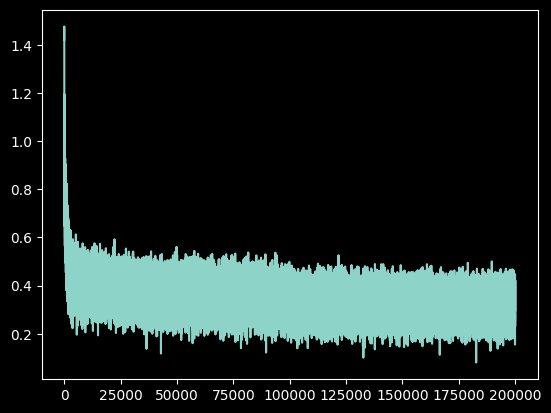

In [28]:
plt.plot(stepi, lossi)

In [29]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.1230, device='cuda:0', grad_fn=<NllLossBackward0>)

In [30]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.1627, device='cuda:0', grad_fn=<NllLossBackward0>)

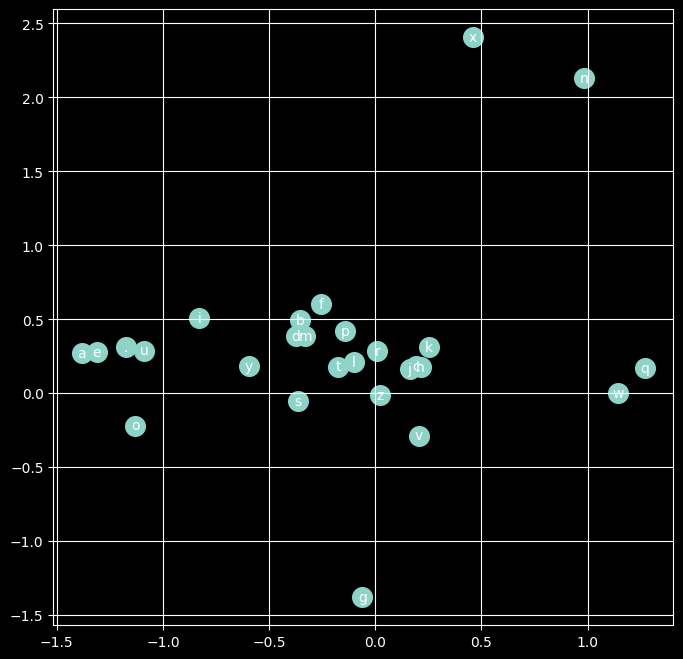

In [32]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].to('cpu').data, C[:,1].to('cpu').data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [33]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [35]:
# sample from the model
g = torch.Generator(device=torch.device('cuda') if torch.cuda.is_available() else None).manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context], device=torch.device('cuda') if torch.cuda.is_available() else None)] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).to('cuda' if torch.cuda.is_available() else 'cpu').item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break

    print(''.join(itos[i] for i in out))

brenten.
ezrindricelijahna.
bryne.
breid.
jomurah.
emincqyanna.
georgendin.
meth.
breyloni.
abshataly.
kengeldyn.
drah.
aan.
jurlana.
derna.
driel.
thi.
bravors.
adrithi.
pra.
